170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Filtered Train Data Shape: (10000, 32, 32, 3)
Filtered Test Data Shape: (2000, 32, 32, 3)
Resizing images to (128, 128)...
Train Data Shape: (10000, 128, 128, 3), Labels Shape: (10000, 2)
Test Data Shape: (2000, 128, 128, 3), Labels Shape: (2000, 2)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting Training with Metrics...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7255 - loss: 0.5304Epoch 1 - Fisher Raw: 0.0033, Features: 0.4641
Epoch 1 - KL: 8.7142, Chernoff: 0.0382
313/313 ━━━━━━━━━━━━━━━━━━━━ 88s 252ms/step - accuracy: 0.7257 - loss: 0.5302 - val_accuracy: 0.8230 - val_loss: 0.4132
Epoch 2/10
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8709 - loss: 0.3162Epoch 2 - Fisher Raw: 0.0033, Features: 0.7095
Epoch 2 - KL: 29.4648, Chernoff: 0.0063
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 235ms/step - accuracy: 0.8709 - loss: 0.3162 - val_accuracy: 0.8440 - val_loss: 0.3670
Epoch 3/10
312/313 ━━━━━━━━

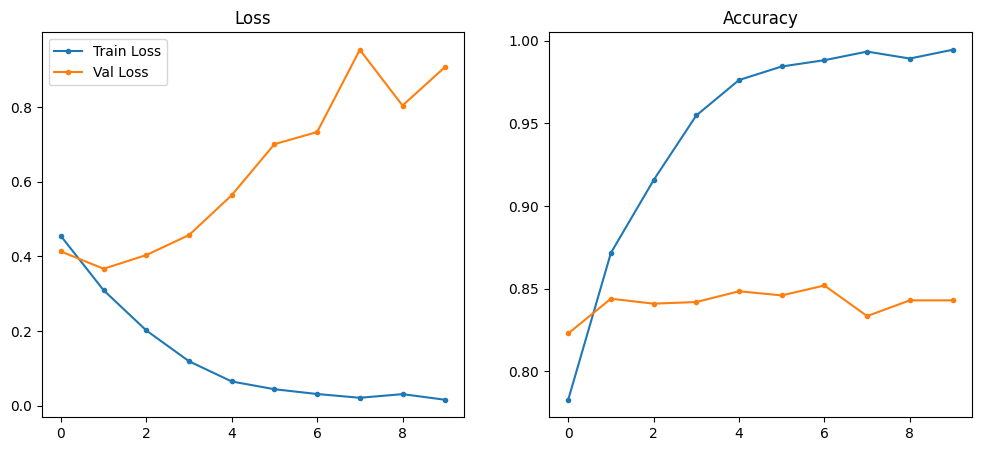

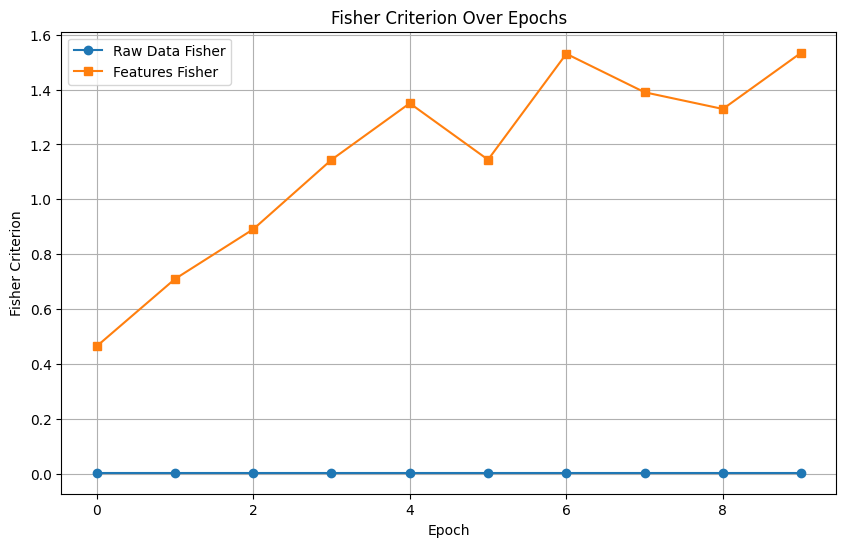

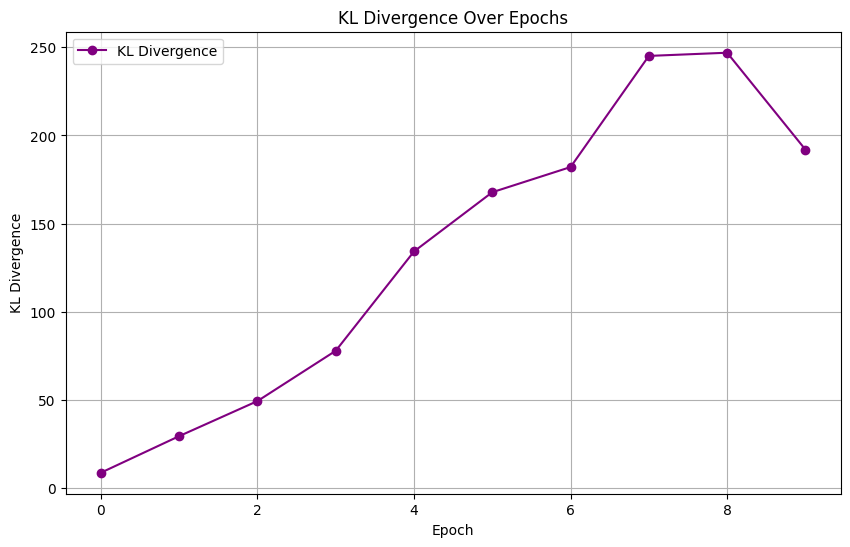

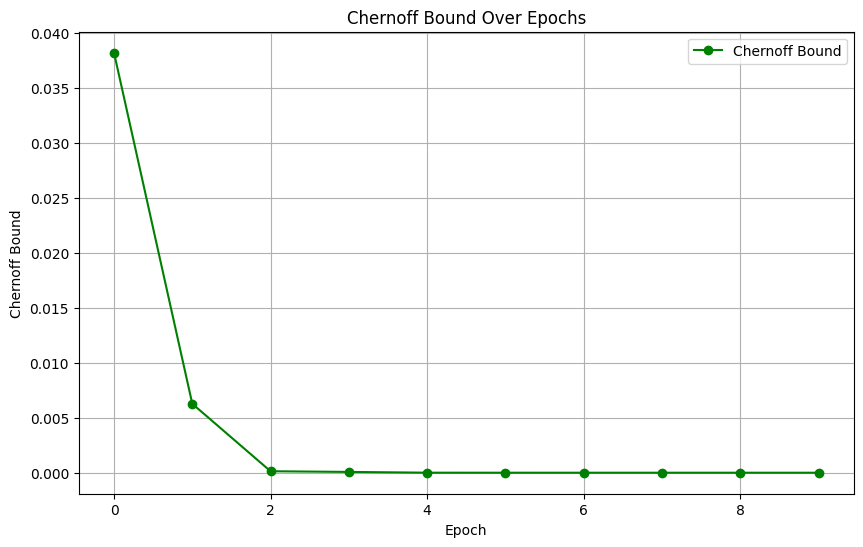

Generating Video...
Video Ready!


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from IPython.display import HTML
from base64 import b64encode
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
# Load Dataset
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
train_labels = train_labels.flatten()
test_labels = test_labels.flatten()
# Data Preparation
class_a = 3
class_b = 5
# Filter training data
train_mask = (train_labels == class_a) | (train_labels == class_b)
X_train_bin = train_images[train_mask]
y_train_bin = train_labels[train_mask]
# Filter test data
test_mask = (test_labels == class_a) | (test_labels == class_b)
X_test_bin = test_images[test_mask]
y_test_bin = test_labels[test_mask]
# Clean up original large arrays to save RAM
del train_images, test_images, train_labels, test_labels
import gc
gc.collect()
print(f"Filtered Train Data Shape: {X_train_bin.shape}")
print(f"Filtered Test Data Shape: {X_test_bin.shape}")
# Convert labels to 0 and 1
y_train_bin = np.where(y_train_bin == class_a, 0, 1)
y_test_bin = np.where(y_test_bin == class_a, 0, 1)
# Resize images
TARGET_SIZE = (128, 128)
print(f"Resizing images to {TARGET_SIZE}...")
X_train_resized = tf.image.resize(X_train_bin, TARGET_SIZE).numpy()
X_test_resized = tf.image.resize(X_test_bin, TARGET_SIZE).numpy()
# Normalize pixel values
X_train_resized = X_train_resized / 255.0
X_test_resized = X_test_resized / 255.0
# One-hot encoding
y_train_onehot = to_categorical(y_train_bin, num_classes=2)
y_test_onehot = to_categorical(y_test_bin, num_classes=2)
print(f"Train Data Shape: {X_train_resized.shape}, Labels Shape: {y_train_onehot.shape}")
print(f"Test Data Shape: {X_test_resized.shape}, Labels Shape: {y_test_onehot.shape}")
# Model Definition
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False
# Add custom top layers
x = Flatten()(base_model.output)
x = Dense(256, activation='relu', name='pre_fc_layer')(x)
output = Dense(2, activation='softmax')(x)
# Create the full model
model = Model(inputs=base_model.input, outputs=output)
# Fine-tune: Unfreeze the last 4 layers of VGG16
for layer in base_model.layers[-4:]:
    layer.trainable = True
# Custom Metrics Functions
def fisher_criterion(features, labels):
    unique_classes = np.unique(labels)
    class_means = {cls: features[labels == cls].mean(axis=0) for cls in unique_classes}
    overall_mean = features.mean(axis=0)
    s_b = sum([len(features[labels == cls]) * np.linalg.norm(class_means[cls] - overall_mean) ** 2 for cls in unique_classes])
    s_w = sum([np.sum(np.linalg.norm(features[labels == cls] - class_means[cls], axis=1) ** 2) for cls in unique_classes])
    return s_b / s_w if s_w != 0 else 0
def kl_divergence(p, q):
    p = np.clip(p, 1e-10, 1)
    q = np.clip(q, 1e-10, 1)
    return np.sum(p * np.log(p / q))
def chernoff_bound(mean1, mean2, cov1, cov2):
    beta = 0.5
    mean_diff = mean1 - mean2
    cov_beta = beta * cov1 + (1 - beta) * cov2
    try:
        inv_cov_beta = np.linalg.inv(cov_beta)
        exponent = -0.5 * np.dot(np.dot(mean_diff.T, inv_cov_beta), mean_diff)
        return np.exp(exponent) / np.sqrt(np.linalg.det(cov_beta))
    except:
        return 0.0
class FisherCriterionCallback(tf.keras.callbacks.Callback):
    def __init__(self, x_raw, y_raw, x_features, y_labels):
        super().__init__()
        self.x_raw = x_raw
        self.y_raw = y_raw
        self.x_features = x_features
        self.y_labels = y_labels
        self.epoch_fisher_scores = {'raw': [], 'features': []}
    def on_epoch_end(self, epoch, logs=None):
        # Fisher on Raw Data
        fisher_raw = fisher_criterion(self.x_raw.reshape(self.x_raw.shape[0], -1), self.y_raw.flatten())
        self.epoch_fisher_scores['raw'].append(fisher_raw)
        # Fisher on Extracted Features
        feature_extractor = Model(inputs=self.model.input, outputs=self.model.get_layer('pre_fc_layer').output)
        features = feature_extractor.predict(self.x_features, verbose=0)
        fisher_features = fisher_criterion(features, np.argmax(self.y_labels, axis=1))
        self.epoch_fisher_scores['features'].append(fisher_features)
        print(f"Epoch {epoch + 1} - Fisher Raw: {fisher_raw:.4f}, Features: {fisher_features:.4f}")
class MetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, x_features, y_labels, num_epochs):
        super().__init__()
        self.x_features = x_features
        self.y_labels = y_labels
        self.num_epochs = num_epochs
        self.kl_distances = []
        self.chernoff_bounds = []
        self.pca_centroids = []
    def on_epoch_end(self, epoch, logs=None):
        feature_extractor = Model(inputs=self.model.input, outputs=self.model.get_layer('pre_fc_layer').output)
        features = feature_extractor.predict(self.x_features, verbose=0)
        class1_features = features[np.argmax(self.y_labels, axis=1) == 0]
        class2_features = features[np.argmax(self.y_labels, axis=1) == 1]
        # KL Divergence
        kl_dist = kl_divergence(class1_features.mean(axis=0), class2_features.mean(axis=0))
        self.kl_distances.append(kl_dist)
        # PCA & GMM for Chernoff
        pca = PCA(n_components=2)
        features_pca = pca.fit_transform(features)
        class1_pca = features_pca[np.argmax(self.y_labels, axis=1) == 0]
        class2_pca = features_pca[np.argmax(self.y_labels, axis=1) == 1]
        if len(class1_pca) > 3 and len(class2_pca) > 3:
            gmm1 = GaussianMixture(n_components=3, random_state=42).fit(class1_pca)
            gmm2 = GaussianMixture(n_components=3, random_state=42).fit(class2_pca)
            self.pca_centroids.append((gmm1.means_, gmm2.means_))
            ch_bound = chernoff_bound(
                gmm1.means_.mean(axis=0), gmm2.means_.mean(axis=0),
                np.cov(class1_pca.T), np.cov(class2_pca.T)
            )
            self.chernoff_bounds.append(ch_bound)
        else:
            self.chernoff_bounds.append(0.0)
            self.pca_centroids.append((np.zeros((3,2)), np.zeros((3,2))))
        print(f"Epoch {epoch + 1} - KL: {kl_dist:.4f}, Chernoff: {self.chernoff_bounds[-1]:.4f}")
# Training (With Callbacks)
# Compile the model
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# Initialize Callbacks
fisher_callback = FisherCriterionCallback(
    x_raw=X_train_bin,
    y_raw=y_train_bin,
    x_features=X_train_resized,
    y_labels=y_train_onehot
)
metrics_callback = MetricsCallback(
    x_features=X_train_resized,
    y_labels=y_train_onehot,
    num_epochs=10
)
print("Starting Training with Metrics...")
history = model.fit(
    X_train_resized, y_train_onehot,
    validation_data=(X_test_resized, y_test_onehot),
    epochs=10,
    batch_size=32,
    callbacks=[fisher_callback, metrics_callback],
    verbose=1
)
# Plot Loss/Accuracy (Standard Training Plots)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', marker='.')
plt.plot(history.history['val_loss'], label='Val Loss', marker='.')
plt.title('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc', marker='.')
plt.plot(history.history['val_accuracy'], label='Val Acc', marker='.')
plt.title('Accuracy')
plt.show()
# Fisher Plot
plt.figure(figsize=(10, 6))
plt.plot(fisher_callback.epoch_fisher_scores['raw'], label='Raw Data Fisher', marker='o')
plt.plot(fisher_callback.epoch_fisher_scores['features'], label='Features Fisher', marker='s')
plt.title("Fisher Criterion Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Fisher Criterion")
plt.legend()
plt.grid()
plt.show()
# KL Plot
plt.figure(figsize=(10, 6))
plt.plot(metrics_callback.kl_distances, label='KL Divergence', marker='o', color='purple')
plt.title("KL Divergence Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("KL Divergence")
plt.legend()
plt.grid()
plt.show()
# Chernoff Plot
plt.figure(figsize=(10, 6))
plt.plot(metrics_callback.chernoff_bounds, label='Chernoff Bound', marker='o', color='green')
plt.title("Chernoff Bound Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Chernoff Bound")
plt.legend()
plt.grid()
plt.show()
# Video Generation
print("Generating Video...")
video_path = 'cluster_centroids.avi'
frame_size = (600, 600)
fps = 1
video = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*'XVID'), fps, frame_size)
centroids_data = metrics_callback.pca_centroids
if len(centroids_data) > 0:
    for epoch, (centroids1, centroids2) in enumerate(centroids_data):
        plt.figure(figsize=(6, 6))
        plt.scatter(centroids1[:, 0], centroids1[:, 1], label='Class 0 Centroids', c='blue', s=100, marker='x')
        plt.scatter(centroids2[:, 0], centroids2[:, 1], label='Class 1 Centroids', c='red', s=100, marker='x')
        plt.title(f"PCA Cluster Centroids - Epoch {epoch + 1}")
        plt.xlabel("PCA 1")
        plt.ylabel("PCA 2")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.savefig('temp_frame.png')
        plt.close()
        frame = cv2.imread('temp_frame.png')
        if frame is not None:
            frame_resized = cv2.resize(frame, frame_size)
            video.write(frame_resized)
    video.release()
    if os.path.exists('temp_frame.png'):
        os.remove('temp_frame.png')
    # Convert to MP4 and Display
    if os.path.exists('/usr/bin/ffmpeg'):
        os.system(f"ffmpeg -i {video_path} cluster_centroids.mp4 -y -loglevel quiet")
        video_path_mp4 = 'cluster_centroids.mp4'
        if os.path.exists(video_path_mp4):
            with open(video_path_mp4, 'rb') as f:
                video_data = f.read()
            video_base64 = b64encode(video_data).decode()
            video_html = f'<video width="600" height="600" controls><source src="data:video/mp4;base64,{video_base64}" type="video/mp4"></video>'
            print("Video Ready!")
            display(HTML(video_html))
    else:
        print("FFmpeg not found. AVI saved.")
else:
    print("No data for video.")

Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 96, 96, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 48, 48, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pre_fc_layer (Dense)            │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,897,162 (60.64 MB)

 Trainable params: 8,261,898 (31.52 MB)

...

/tmp/ipython-input-2229092407.py:200: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  exponent = -0.5 * beta * (1 - beta) * float(diff.T @ inv_cov_beta @ diff)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 127s 41ms/step - accuracy: 0.9837 - loss: 0.0493 - val_accuracy: 0.8589 - val_loss: 0.6228
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9846 - loss: 0.0441 -> Fisher (10-class subset): 1.7968
 -> Epoch 8: KLsym=22.7213, Chernoff=0.1786
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 129s 41ms/step - accuracy: 0.9846 - loss: 0.0441 - val_accuracy: 0.8587 - val_loss: 0.6940
Epoch 9/10
   3/3125 ━━━━━━━━━━━━━━━━━━━━ 1:51 36ms/step - accuracy: 0.9931 - loss: 0.0168

/tmp/ipython-input-2229092407.py:200: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  exponent = -0.5 * beta * (1 - beta) * float(diff.T @ inv_cov_beta @ diff)


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 127s 41ms/step - accuracy: 0.9854 - loss: 0.0429 - val_accuracy: 0.8609 - val_loss: 0.7211
Epoch 10/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9879 - loss: 0.0381 -> Fisher (10-class subset): 1.7601
 -> Epoch 10: KLsym=20.0701, Chernoff=0.1960
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 129s 41ms/step - accuracy: 0.9879 - loss: 0.0381 - val_accuracy: 0.8548 - val_loss: 0.7516


/tmp/ipython-input-2229092407.py:200: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  exponent = -0.5 * beta * (1 - beta) * float(diff.T @ inv_cov_beta @ diff)


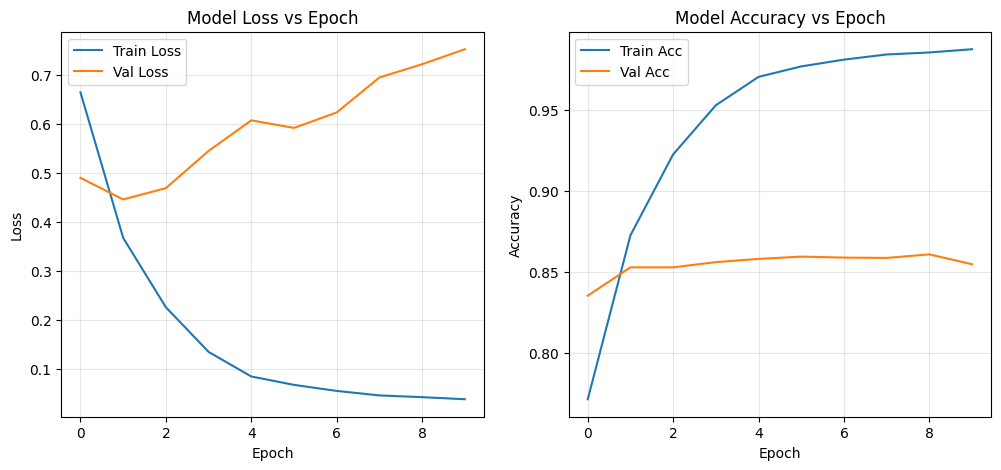

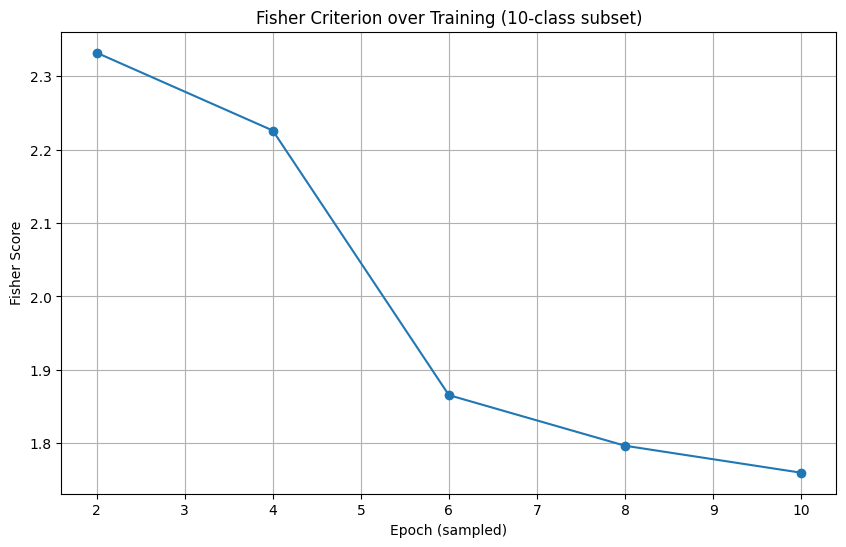

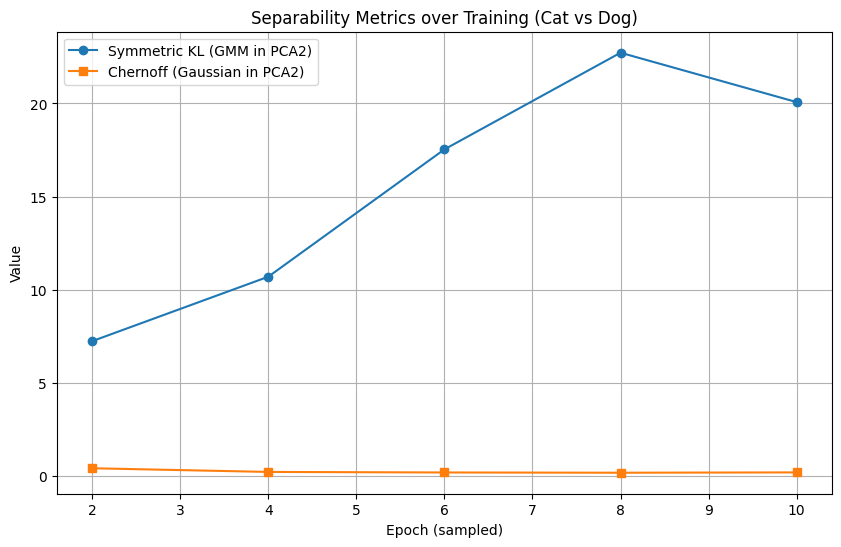


Generating t-SNE plot (final features)...


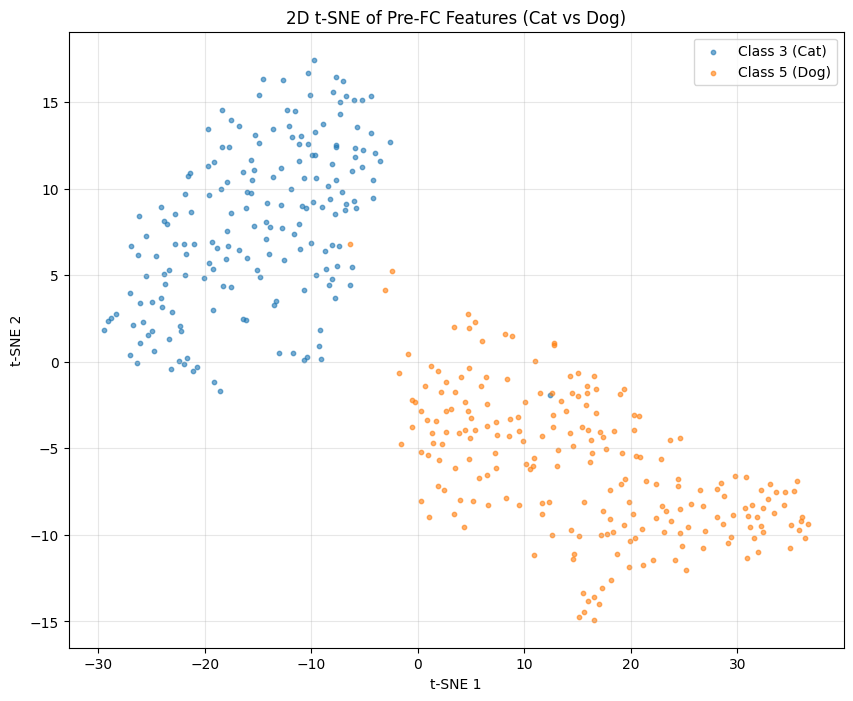


Generating Video of Cluster Centroids...


14582

In [ ]:
import os, gc, cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback

from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE

from IPython.display import HTML, display
from base64 import b64encode
np.random.seed(42)
tf.random.set_seed(42)
# Settings (Colab-friendly)
TARGET_SIZE = (96, 96)
BATCH_SIZE = 16
EPOCHS = 10
fisher_subset_size = 800
analysis_subset_size = 400
ANALYZE_EVERY = 2   # run heavy analysis every 2 epochs
KL_SAMPLES = 800    # Monte Carlo samples for KL
num_classes = 10
class_a, class_b = 3, 5  # cat vs dog for analysis only
# Load data (ALL 10 classes)
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
train_labels = train_labels.flatten()
test_labels = test_labels.flatten()
print("Train:", train_images.shape, train_labels.shape)
print("Test :", test_images.shape, test_labels.shape)
# tf.data pipelines
def preprocess(image, label):
    image = tf.image.resize(image, TARGET_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, depth=num_classes)
    return image, label
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_images, train_labels))
    .shuffle(20000)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    tf.data.Dataset.from_tensor_slices((test_images, test_labels))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
# Build model
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3)
)
# Freeze initially
for layer in base_model.layers:
    layer.trainable = False
x = Flatten()(base_model.output)
x = Dense(256, activation="relu", name="pre_fc_layer")(x)
out = Dense(num_classes, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=out)
# Fine-tune last 4 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()
# Prepare subsets for metrics
# Multi-class subset for Fisher
fisher_idx = np.random.choice(np.arange(len(train_images)), size=fisher_subset_size, replace=False)
X_fisher = train_images[fisher_idx]
y_fisher_int = train_labels[fisher_idx]
# Cat/Dog subset for KL/Chernoff/t-SNE/video
mask_bin = (train_labels == class_a) | (train_labels == class_b)
bin_idx_all = np.where(mask_bin)[0]
analysis_idx = np.random.choice(bin_idx_all, size=analysis_subset_size, replace=False)
X_analysis = train_images[analysis_idx]
y_analysis_int = train_labels[analysis_idx]
def resize_np(images):
    imgs = tf.image.resize(images, TARGET_SIZE)
    return (tf.cast(imgs, tf.float32) / 255.0).numpy()
X_fisher_resized = resize_np(X_fisher)
X_analysis_resized = resize_np(X_analysis)
# Metrics helpers
def fisher_criterion_multiclass(features: np.ndarray, labels_int: np.ndarray) -> float:
    classes = np.unique(labels_int)
    if len(classes) < 2:
        return 0.0
    overall_mean = features.mean(axis=0)
    sb, sw = 0.0, 0.0
    for c in classes:
        Xc = features[labels_int == c]
        if len(Xc) < 2:
            continue
        mean_c = Xc.mean(axis=0)
        n_c = len(Xc)
        diff = (mean_c - overall_mean)
        sb += n_c * float(np.dot(diff, diff))
        sw += float(np.sum((Xc - mean_c) ** 2))
    return sb / sw if sw > 0 else 0.0
def kl_divergence_gmm(gmm_p: GaussianMixture, gmm_q: GaussianMixture, n_samples: int = 800) -> float:
    Xp, _ = gmm_p.sample(n_samples)
    logP = gmm_p.score_samples(Xp)
    logQ = gmm_q.score_samples(Xp)
    return float(np.mean(logP - logQ))
def chernoff_gaussian(mean1, cov1, mean2, cov2, beta=0.5) -> float:
    mean1 = np.asarray(mean1).reshape(-1, 1)
    mean2 = np.asarray(mean2).reshape(-1, 1)
    cov1 = np.asarray(cov1)
    cov2 = np.asarray(cov2)
    d = cov1.shape[0]
    eps = 1e-6
    cov1 = cov1 + np.eye(d) * eps
    cov2 = cov2 + np.eye(d) * eps
    cov_beta = beta * cov1 + (1 - beta) * cov2
    cov_beta = cov_beta + np.eye(d) * eps
    try:
        inv_cov_beta = np.linalg.inv(cov_beta)
        diff = (mean1 - mean2)
        exponent = -0.5 * beta * (1 - beta) * float(diff.T @ inv_cov_beta @ diff)
        det_beta = np.linalg.det(cov_beta)
        det1 = np.linalg.det(cov1)
        det2 = np.linalg.det(cov2)
        coeff = (det1 ** beta) * (det2 ** (1 - beta))
        coeff = coeff / (det_beta + 1e-12)
        val = np.exp(exponent) * np.sqrt(max(coeff, 1e-12))
        return float(val)
    except:
        return 0.0
# Callbacks
class FisherCallback(Callback):
    def __init__(self, x_fisher_resized, y_fisher_int, analyze_every=2):
        super().__init__()
        self.x = x_fisher_resized
        self.y = y_fisher_int
        self.analyze_every = analyze_every
        self.history = []
        self.feat_ext = None
    def on_train_begin(self, logs=None):
        self.feat_ext = Model(inputs=self.model.input, outputs=self.model.get_layer("pre_fc_layer").output)
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.analyze_every != 0:
            return
        feats = self.feat_ext.predict(self.x, verbose=0)
        score = fisher_criterion_multiclass(feats, self.y)
        self.history.append(score)
        print(f" -> Fisher (10-class subset): {score:.4f}")
class AnalysisCallback(Callback):
    def __init__(self, x_analysis_resized, y_analysis_int, class_a, class_b,
                 analyze_every=2, kl_samples=800):
        super().__init__()
        self.x = x_analysis_resized
        self.y = y_analysis_int
        self.class_a = class_a
        self.class_b = class_b
        self.analyze_every = analyze_every
        self.kl_samples = kl_samples
        self.kl_sym_hist = []
        self.chernoff_hist = []
        self.centroids_hist = []
        self.epoch_marks = []  
        self.feat_ext = None
    def on_train_begin(self, logs=None):
        self.feat_ext = Model(inputs=self.model.input, outputs=self.model.get_layer("pre_fc_layer").output)
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.analyze_every != 0:
            return
        feats = self.feat_ext.predict(self.x, verbose=0)
        mask_a = (self.y == self.class_a)
        mask_b = (self.y == self.class_b)
        # PCA to 2D for GMM + Chernoff
        pca = PCA(n_components=2, random_state=42)
        feats_2d = pca.fit_transform(feats)
        feats_2d_a = feats_2d[mask_a]
        feats_2d_b = feats_2d[mask_b]
        # Fit GMMs
        gmm_a = GaussianMixture(n_components=3, random_state=42).fit(feats_2d_a)
        gmm_b = GaussianMixture(n_components=3, random_state=42).fit(feats_2d_b)
        # KL distances (Monte Carlo)
        kl_ab = kl_divergence_gmm(gmm_a, gmm_b, n_samples=self.kl_samples)
        kl_ba = kl_divergence_gmm(gmm_b, gmm_a, n_samples=self.kl_samples)
        kl_sym = 0.5 * (kl_ab + kl_ba)
        self.kl_sym_hist.append(kl_sym)
        # Chernoff on Gaussian approximation (PCA2)
        mean_a = feats_2d_a.mean(axis=0)
        mean_b = feats_2d_b.mean(axis=0)
        cov_a = np.cov(feats_2d_a.T)
        cov_b = np.cov(feats_2d_b.T)
        cb = chernoff_gaussian(mean_a, cov_a, mean_b, cov_b, beta=0.5)
        self.chernoff_hist.append(cb)
        # Save centroids for video
        self.centroids_hist.append((gmm_a.means_, gmm_b.means_))
        self.epoch_marks.append(epoch + 1)
        print(f" -> Epoch {epoch+1}: KLsym={kl_sym:.4f}, Chernoff={cb:.4f}")
# Initialize callbacks
fisher_cb = FisherCallback(X_fisher_resized, y_fisher_int, analyze_every=ANALYZE_EVERY)
analysis_cb = AnalysisCallback(
    X_analysis_resized, y_analysis_int, class_a, class_b,
    analyze_every=ANALYZE_EVERY, kl_samples=KL_SAMPLES
)
# Train
print("\nStarting Training...")
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=[fisher_cb, analysis_cb],
    verbose=1
)
# Loss/Accuracy plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Model Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# Fisher plot 
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(fisher_cb.history) + 1) * ANALYZE_EVERY, fisher_cb.history, marker="o")
plt.title("Fisher Criterion over Training (10-class subset)")
plt.xlabel("Epoch (sampled)")
plt.ylabel("Fisher Score")
plt.grid(True)
plt.show()
# KL + Chernoff plot 
plt.figure(figsize=(10, 6))
plt.plot(analysis_cb.epoch_marks, analysis_cb.kl_sym_hist, marker="o", label="Symmetric KL (GMM in PCA2)")
plt.plot(analysis_cb.epoch_marks, analysis_cb.chernoff_hist, marker="s", label="Chernoff (Gaussian in PCA2)")
plt.title("Separability Metrics over Training (Cat vs Dog)")
plt.xlabel("Epoch (sampled)")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()
# t-SNE at the end (cat vs dog)
print("\nGenerating t-SNE plot (final features)...")
feat_extractor = Model(inputs=model.input, outputs=model.get_layer("pre_fc_layer").output)
final_feats = feat_extractor.predict(X_analysis_resized, verbose=0)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
feats_tsne = tsne.fit_transform(final_feats)
plt.figure(figsize=(10, 8))
plt.scatter(feats_tsne[y_analysis_int == class_a, 0], feats_tsne[y_analysis_int == class_a, 1],
            label=f"Class {class_a} (Cat)", alpha=0.6, s=10)
plt.scatter(feats_tsne[y_analysis_int == class_b, 0], feats_tsne[y_analysis_int == class_b, 1],
            label=f"Class {class_b} (Dog)", alpha=0.6, s=10)
plt.title("2D t-SNE of Pre-FC Features (Cat vs Dog)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# Video generation of GMM centroids (PCA2)
print("\nGenerating Video of Cluster Centroids...")
video_path = "cluster_centroids.avi"
frame_size = (600, 600)
fps = 1
video = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*"XVID"), fps, frame_size)
for i, (c_a, c_b) in enumerate(analysis_cb.centroids_hist):
    epoch_mark = analysis_cb.epoch_marks[i]
    plt.figure(figsize=(6, 6))
    plt.scatter(c_a[:, 0], c_a[:, 1], label=f"Class {class_a}", s=100, marker="x")
    plt.scatter(c_b[:, 0], c_b[:, 1], label=f"Class {class_b}", s=100, marker="x")
    plt.title(f"PCA2 GMM Centroids - Epoch {epoch_mark}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("temp_frame.png")
    plt.close()
    frame = cv2.imread("temp_frame.png")
    if frame is not None:
        frame = cv2.resize(frame, frame_size)
        video.write(frame)
video.release()
if os.path.exists("temp_frame.png"):
    os.remove("temp_frame.png")
# Convert to MP4 & display (if ffmpeg available)
if os.path.exists("/usr/bin/ffmpeg"):
    os.system(f"ffmpeg -i {video_path} cluster_centroids.mp4 -y -loglevel quiet")
    if os.path.exists("cluster_centroids.mp4"):
        with open("cluster_centroids.mp4", "rb") as f:
            mp4_data = f.read()
        data_url = f"data:video/mp4;base64,{b64encode(mp4_data).decode()}"
        display(HTML(f'<video width="600" controls src="{data_url}"></video>'))
else:
    print(f"Video saved to {video_path}")
# Optional cleanup
gc.collect()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 96, 96, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 48, 48, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pre_fc_layer (Dense)            │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,897,162 (60.64 MB)

 Trainable params: 8,261,898 (31.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)


Starting Training...
Epoch 1/10
3124/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6937 - loss: 0.8783 -> Fisher (10-class subset): 2.1474
 -> Epoch 1: KLsym=3.5716, Chernoff=0.5136
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 135s 41ms/step - accuracy: 0.6937 - loss: 0.8782 - val_accuracy: 0.8276 - val_loss: 0.4983
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8702 - loss: 0.3766 -> Fisher (10-class subset): 2.2140
 -> Epoch 2: KLsym=7.7585, Chernoff=0.3758
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 127s 41ms/step - accuracy: 0.8702 - loss: 0.3766 - val_accuracy: 0.8505 - val_loss: 0.4479
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9217 - loss: 0.2251 -> Fisher (10-class subset): 1.9202
 -> Epoch 3: KLsym=6.4016, Chernoff=0.3310
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 135s 43ms/step - accuracy: 0.9217 - loss: 0.2251 - val_accuracy: 0.8425 - val_loss: 0.5226
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9554 - loss: 0.1289 -> Fisher (10-class

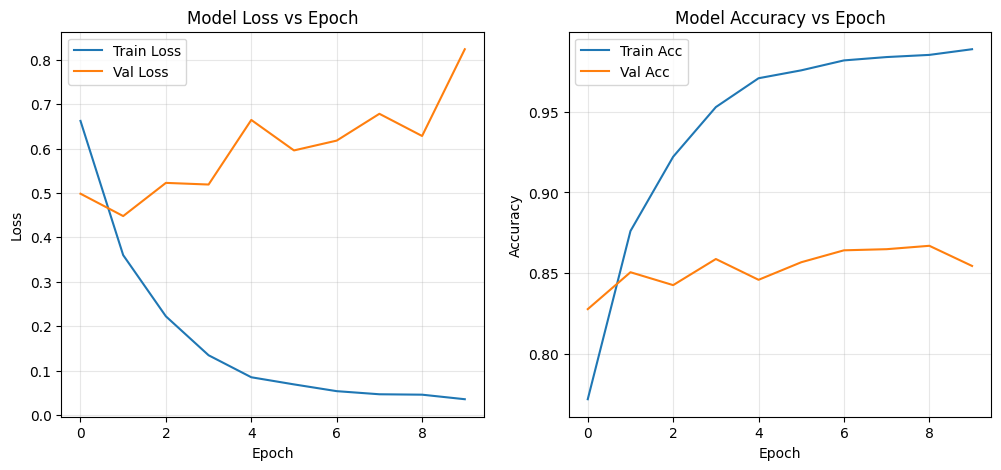

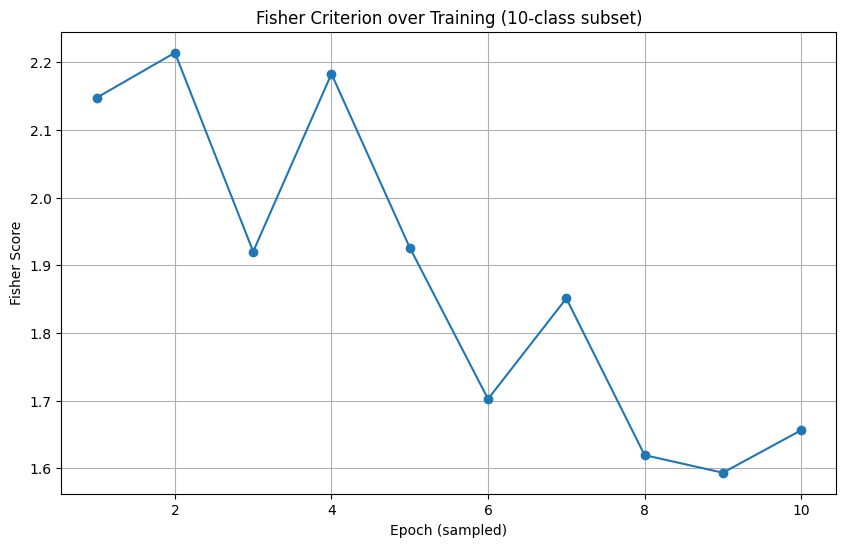

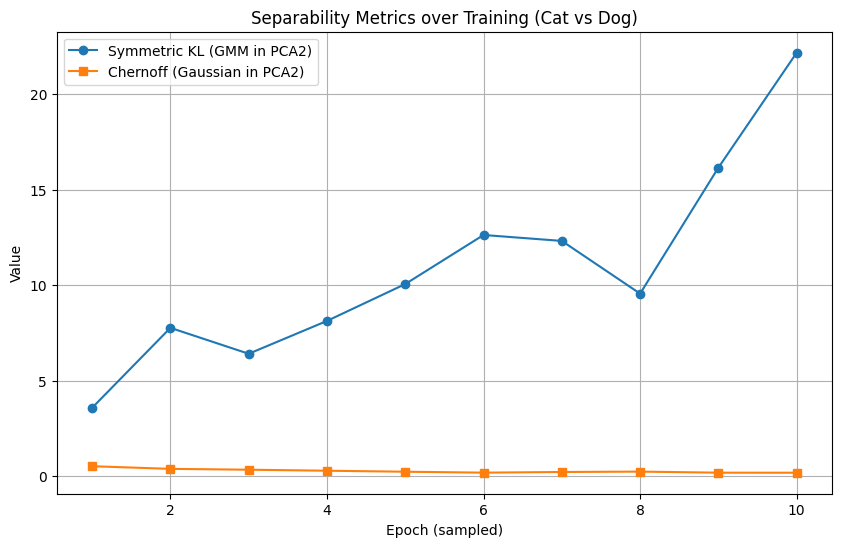


Generating t-SNE plot (final features)...


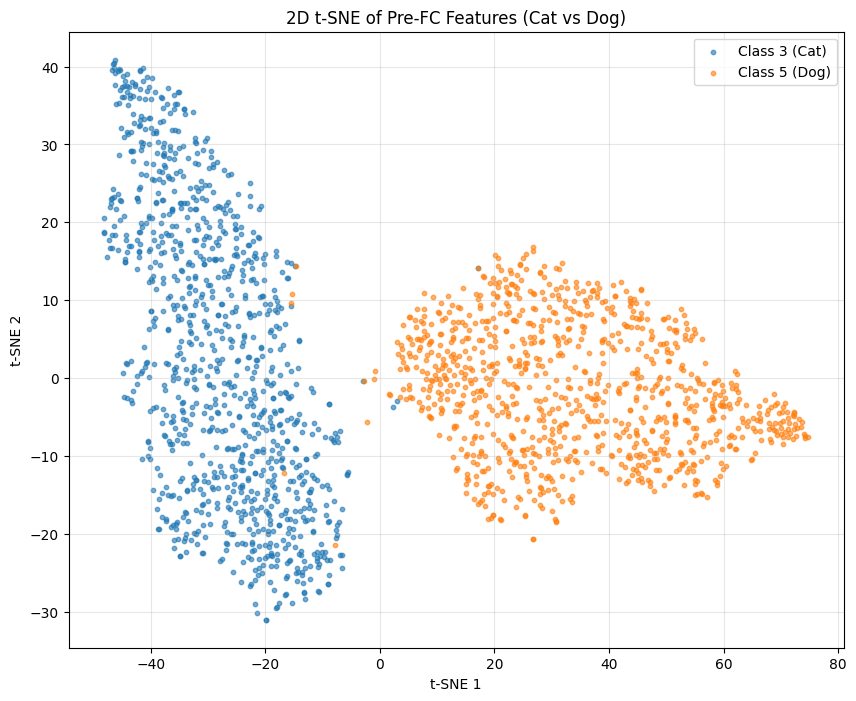


Generating Video of Cluster Centroids...


389

In [1]:
import os, gc, cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from IPython.display import HTML, display
from base64 import b64encode
np.random.seed(42)
tf.random.set_seed(42)
TARGET_SIZE = (96, 96)
BATCH_SIZE = 16
EPOCHS = 10
fisher_subset_size = 800
analysis_subset_size = 400
ANALYZE_EVERY = 1
KL_SAMPLES = 800
num_classes = 10
class_a, class_b = 3, 5
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
train_labels = train_labels.flatten()
test_labels = test_labels.flatten()
print("Train:", train_images.shape, train_labels.shape)
print("Test :", test_images.shape, test_labels.shape)
def preprocess(image, label):
    image = tf.image.resize(image, TARGET_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, depth=num_classes)
    return image, label
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_images, train_labels))
    .shuffle(20000)
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    tf.data.Dataset.from_tensor_slices((test_images, test_labels))
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3)
)
for layer in base_model.layers:
    layer.trainable = False
x = Flatten()(base_model.output)
x = Dense(256, activation="relu", name="pre_fc_layer")(x)
out = Dense(num_classes, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=out)
for layer in base_model.layers[-4:]:
    layer.trainable = True
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()
fisher_idx = np.random.choice(np.arange(len(train_images)), size=fisher_subset_size, replace=False)
X_fisher = train_images[fisher_idx]
y_fisher_int = train_labels[fisher_idx]
mask_bin = (train_labels == class_a) | (train_labels == class_b)
bin_idx_all = np.where(mask_bin)[0]
analysis_idx = np.random.choice(bin_idx_all, size=min(analysis_subset_size, len(bin_idx_all)), replace=False)
X_analysis = train_images[analysis_idx]
y_analysis_int = train_labels[analysis_idx]
tsne_subset_size = min(len(bin_idx_all), 2000)
tsne_idx = np.random.choice(bin_idx_all, size=tsne_subset_size, replace=False) if len(bin_idx_all) > tsne_subset_size else bin_idx_all
X_tsne = train_images[tsne_idx]
y_tsne_int = train_labels[tsne_idx]
def resize_np(images):
    imgs = tf.image.resize(images, TARGET_SIZE)
    return (tf.cast(imgs, tf.float32) / 255.0).numpy()
X_fisher_resized = resize_np(X_fisher)
X_analysis_resized = resize_np(X_analysis)
X_tsne_resized = resize_np(X_tsne)
def fisher_criterion_multiclass(features: np.ndarray, labels_int: np.ndarray) -> float:
    classes = np.unique(labels_int)
    if len(classes) < 2:
        return 0.0
    overall_mean = features.mean(axis=0)
    sb, sw = 0.0, 0.0
    for c in classes:
        Xc = features[labels_int == c]
        if len(Xc) < 2:
            continue
        mean_c = Xc.mean(axis=0)
        n_c = len(Xc)
        diff = (mean_c - overall_mean)
        sb += n_c * float(np.dot(diff, diff))
        sw += float(np.sum((Xc - mean_c) ** 2))
    return sb / sw if sw > 0 else 0.0
def kl_divergence_gmm(gmm_p: GaussianMixture, gmm_q: GaussianMixture, n_samples: int = 800) -> float:
    Xp, _ = gmm_p.sample(n_samples)
    logP = gmm_p.score_samples(Xp)
    logQ = gmm_q.score_samples(Xp)
    return float(np.mean(logP - logQ))
def chernoff_gaussian(mean1, cov1, mean2, cov2, beta=0.5) -> float:
    mean1 = np.asarray(mean1).reshape(-1, 1)
    mean2 = np.asarray(mean2).reshape(-1, 1)
    cov1 = np.asarray(cov1)
    cov2 = np.asarray(cov2)
    d = cov1.shape[0]
    eps = 1e-6
    cov1 = cov1 + np.eye(d) * eps
    cov2 = cov2 + np.eye(d) * eps
    cov_beta = beta * cov1 + (1 - beta) * cov2
    cov_beta = cov_beta + np.eye(d) * eps
    try:
        inv_cov_beta = np.linalg.inv(cov_beta)
        diff = (mean1 - mean2)
        exponent = -0.5 * beta * (1 - beta) * (diff.T @ inv_cov_beta @ diff).item()
        det_beta = np.linalg.det(cov_beta)
        det1 = np.linalg.det(cov1)
        det2 = np.linalg.det(cov2)
        coeff = (det1 ** beta) * (det2 ** (1 - beta))
        coeff = coeff / (det_beta + 1e-12)
        val = np.exp(exponent) * np.sqrt(max(coeff, 1e-12))
        return float(val)
    except:
        return 0.0
class FisherCallback(Callback):
    def __init__(self, x_fisher_resized, y_fisher_int, analyze_every=1):
        super().__init__()
        self.x = x_fisher_resized
        self.y = y_fisher_int
        self.analyze_every = analyze_every
        self.history = []
        self.feat_ext = None
    def on_train_begin(self, logs=None):
        self.feat_ext = Model(inputs=self.model.input, outputs=self.model.get_layer("pre_fc_layer").output)
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.analyze_every != 0:
            return
        feats = self.feat_ext.predict(self.x, verbose=0)
        score = fisher_criterion_multiclass(feats, self.y)
        self.history.append(score)
        print(f" -> Fisher (10-class subset): {score:.4f}")
class AnalysisCallback(Callback):
    def __init__(self, x_analysis_resized, y_analysis_int, class_a, class_b, analyze_every=1, kl_samples=800):
        super().__init__()
        self.x = x_analysis_resized
        self.y = y_analysis_int
        self.class_a = class_a
        self.class_b = class_b
        self.analyze_every = analyze_every
        self.kl_samples = kl_samples
        self.kl_sym_hist = []
        self.chernoff_hist = []
        self.centroids_hist = []
        self.epoch_marks = []
        self.feat_ext = None
    def on_train_begin(self, logs=None):
        self.feat_ext = Model(inputs=self.model.input, outputs=self.model.get_layer("pre_fc_layer").output)
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.analyze_every != 0:
            return
        feats = self.feat_ext.predict(self.x, verbose=0)
        mask_a = (self.y == self.class_a)
        mask_b = (self.y == self.class_b)
        pca = PCA(n_components=2, random_state=42)
        feats_2d = pca.fit_transform(feats)
        feats_2d_a = feats_2d[mask_a]
        feats_2d_b = feats_2d[mask_b]
        gmm_a = GaussianMixture(n_components=3, random_state=42).fit(feats_2d_a)
        gmm_b = GaussianMixture(n_components=3, random_state=42).fit(feats_2d_b)
        kl_ab = kl_divergence_gmm(gmm_a, gmm_b, n_samples=self.kl_samples)
        kl_ba = kl_divergence_gmm(gmm_b, gmm_a, n_samples=self.kl_samples)
        kl_sym = 0.5 * (kl_ab + kl_ba)
        self.kl_sym_hist.append(kl_sym)
        mean_a = feats_2d_a.mean(axis=0)
        mean_b = feats_2d_b.mean(axis=0)
        cov_a = np.cov(feats_2d_a.T)
        cov_b = np.cov(feats_2d_b.T)
        cb = chernoff_gaussian(mean_a, cov_a, mean_b, cov_b, beta=0.5)
        self.chernoff_hist.append(cb)
        self.centroids_hist.append((gmm_a.means_, gmm_b.means_))
        self.epoch_marks.append(epoch + 1)
        print(f" -> Epoch {epoch+1}: KLsym={kl_sym:.4f}, Chernoff={cb:.4f}")
fisher_cb = FisherCallback(X_fisher_resized, y_fisher_int, analyze_every=ANALYZE_EVERY)
analysis_cb = AnalysisCallback(X_analysis_resized, y_analysis_int, class_a, class_b, analyze_every=ANALYZE_EVERY, kl_samples=KL_SAMPLES)
print("\nStarting Training...")
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=[fisher_cb, analysis_cb],
    verbose=1
)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Model Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(fisher_cb.history) + 1) * ANALYZE_EVERY, fisher_cb.history, marker="o")
plt.title("Fisher Criterion over Training (10-class subset)")
plt.xlabel("Epoch (sampled)")
plt.ylabel("Fisher Score")
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 6))
plt.plot(analysis_cb.epoch_marks, analysis_cb.kl_sym_hist, marker="o", label="Symmetric KL (GMM in PCA2)")
plt.plot(analysis_cb.epoch_marks, analysis_cb.chernoff_hist, marker="s", label="Chernoff (Gaussian in PCA2)")
plt.title("Separability Metrics over Training (Cat vs Dog)")
plt.xlabel("Epoch (sampled)")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()
print("\nGenerating t-SNE plot (final features)...")
feat_extractor = Model(inputs=model.input, outputs=model.get_layer("pre_fc_layer").output)
final_feats_tsne = feat_extractor.predict(X_tsne_resized, verbose=0)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca", learning_rate="auto")
feats_tsne = tsne.fit_transform(final_feats_tsne)
plt.figure(figsize=(10, 8))
plt.scatter(feats_tsne[y_tsne_int == class_a, 0], feats_tsne[y_tsne_int == class_a, 1], label=f"Class {class_a} (Cat)", alpha=0.6, s=10)
plt.scatter(feats_tsne[y_tsne_int == class_b, 0], feats_tsne[y_tsne_int == class_b, 1], label=f"Class {class_b} (Dog)", alpha=0.6, s=10)
plt.title("2D t-SNE of Pre-FC Features (Cat vs Dog)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("\nGenerating Video of Cluster Centroids...")
video_path = "cluster_centroids.avi"
frame_size = (600, 600)
fps = 1
video = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*"XVID"), fps, frame_size)
for i, (c_a, c_b) in enumerate(analysis_cb.centroids_hist):
    epoch_mark = analysis_cb.epoch_marks[i]
    plt.figure(figsize=(6, 6))
    plt.scatter(c_a[:, 0], c_a[:, 1], label=f"Class {class_a}", s=100, marker="x")
    plt.scatter(c_b[:, 0], c_b[:, 1], label=f"Class {class_b}", s=100, marker="x")
    plt.title(f"PCA2 GMM Centroids - Epoch {epoch_mark}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("temp_frame.png")
    plt.close()
    frame = cv2.imread("temp_frame.png")
    if frame is not None:
        frame = cv2.resize(frame, frame_size)
        video.write(frame)
video.release()
if os.path.exists("temp_frame.png"):
    os.remove("temp_frame.png")
if os.path.exists("/usr/bin/ffmpeg"):
    os.system(f"ffmpeg -i {video_path} cluster_centroids.mp4 -y -loglevel quiet")
    if os.path.exists("cluster_centroids.mp4"):
        with open("cluster_centroids.mp4", "rb") as f:
            mp4_data = f.read()
        data_url = f"data:video/mp4;base64,{b64encode(mp4_data).decode()}"
        display(HTML(f'<video width="600" controls src="{data_url}"></video>'))
else:
    print(f"Video saved to {video_path}")
gc.collect()
